<img src="http://dask.readthedocs.io/en/latest/_images/dask_horizontal.svg"
     align="right"
     width="30%"
     alt="Dask logo\">

# Dask Arrays —— 并行化的 numpy
用分块算法实现并行、大于内存的 n 维数组。

*  **并行**：用上你电脑上的所有核心
*  **大于内存**：把数组切成许多小块，按尽量节省内存占用的顺序处理这些小块，并有效地从磁盘流式读取数据，从而处理比可用内存更大的数据集
*  **分块算法**：把大计算拆成许多小计算来完成


<img src="https://docs.dask.org/en/stable/_images/dask-array.svg" width="40%" align="right">


换句话说，Dask Array 用分块算法实现了 NumPy ndarray 接口的一个子集，把大数组切成许多小数组。这样我们就能用上所有核心，计算比内存更大的数组。这些分块算法由 Dask 任务图来协调。

本 notebook 会先从零实现一些分块算法，建立直觉。
然后我们用 Dask Array、以熟悉的类 NumPy API，并行分析大型数据集。

**相关文档**

* [Array 文档](https://docs.dask.org/en/latest/array.html)
* [Array 视频](https://youtu.be/9h_61hXCDuI)
* [Array API](https://docs.dask.org/en/latest/array-api.html)
* [Array 示例](https://examples.dask.org/array.html)


## 创建数据集


创建本 notebook 会用到的数据集：


In [1]:
%run prep.py -d random

- 正在生成随机数组数据... 

## 启动 Client


In [2]:
from dask.distributed import Client

client = Client(n_workers=4)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 4,Total memory: 15.61 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38541,Workers: 4
Dashboard: http://127.0.0.1:8787/status,Total threads: 4
Started: Just now,Total memory: 15.61 GiB
Comm: tcp://127.0.0.1:45675,Total threads: 1
Dashboard: http://127.0.0.1:38567/status,Memory: 3.90 GiB
Nanny: tcp://127.0.0.1:43033,


## 分块算法速览

我们来并排比较：用 NumPy 数组和 Dask 数组分别对数组元素求和。


In [3]:
import numpy as np
import dask.array as da

In [4]:
# NumPy 数组
a_np = np.ones(10)
a_np


array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

我们知道可以用 `sum()` 求数组元素之和。但为了展示分块操作长什么样，我们改成这样：


In [5]:
a_np_sum = a_np[:5].sum() + a_np[5:].sum()
a_np_sum

10.0

注意上面计算里的两次求和完全独立，因此可以并行。
要用 Dask 数组做到这一点，需要定义我们的“切片”。做法是用变量 `chunks` 指定每个块里要有多少元素。


In [6]:
a_da = da.ones(10, chunks=5)
a_da

dask.array<ones_like, shape=(10,), dtype=float64, chunksize=(5,), chunktype=numpy.ndarray>

**重要！**

要得到两个块，我们指定 `chunks=5`，也就是每个块 5 个元素。


In [7]:
a_da_sum = a_da.sum()
a_da_sum

dask.array<sum-aggregate, shape=(), dtype=float64, chunksize=(), chunktype=numpy.ndarray>

## 任务图

一般来说，人写的代码要靠编译器或解释器，计算机才能理解。转到并行执行时，人们往往希望把一部分责任从编译器转移到人身上，因为分析、优化和执行常常被写进程序本身。这时，我们经常把程序结构显式地表示为程序里的数据。

在 Dask 里我们使用任务调度：把程序拆成许多中等大小的任务（计算单元）。我们把这些任务表示为图中的节点；如果一个任务依赖另一个任务产生的数据，就在它们之间连边。然后请任务调度器按这些数据依赖执行图，并在可能的地方利用并行，让多个独立任务同时运行。


In [8]:
# 用 cytoscape 可视化底层 Dask 图
a_da_sum.visualize(engine="cytoscape")


CytoscapeWidget(cytoscape_layout={'name': 'dagre', 'rankDir': 'BT', 'nodeSep': 10, 'edgeSep': 10, 'spacingFact…

In [9]:
a_da_sum.compute()

10.0

性能对比
------------------------------

来看一个更有意思的例子。我们创建一个服从正态分布的 20,000 × 20,000 数组（下面代码实际用的是 30,000），并沿其中一个轴求均值。

**注意：**

如果你在 Binder 上运行，NumPy 那个例子可能需要改小一点，否则可能内存不够。


### NumPy 版本


In [10]:
%%time
xn = np.random.normal(10, 0.1, size=(30_000, 30_000))
yn = xn.mean(axis=0)
yn

CPU times: user 14.4 s, sys: 841 ms, total: 15.2 s
Wall time: 14.8 s


array([ 9.99963744, 10.00036045,  9.99964785, ..., 10.00058778,
       10.00103584,  9.99831448])

### Dask array 版本


In [11]:
xd = da.random.normal(10, 0.1, size=(30_000, 30_000), chunks=(3000, 3000))
xd

dask.array<normal, shape=(30000, 30000), dtype=float64, chunksize=(3000, 3000), chunktype=numpy.ndarray>

In [12]:
xd.nbytes / 1e9  # 惰性处理的输入有多少 GB


7.2

In [13]:
yd = xd.mean(axis=0)
yd

dask.array<mean_agg-aggregate, shape=(30000,), dtype=float64, chunksize=(3000,), chunktype=numpy.ndarray>

In [14]:
%%time
xd = da.random.normal(10, 0.1, size=(30_000, 30_000), chunks=(3000, 3000))
yd = xd.mean(axis=0)
yd.compute()

CPU times: user 441 ms, sys: 39.5 ms, total: 480 ms
Wall time: 6.22 s


array([ 9.99912112,  9.99951855, 10.0008056 , ...,  9.99889708,
       10.00085268, 10.00066468])

**值得思考的问题：**

* 如果 Dask 的 chunks=(10000,10000)，会发生什么？
* 如果 Dask 的 chunks=(30,30)，会发生什么？


**练习：**

对 Dask 数组，计算 x 与其转置之和沿 `axis=1` 的均值。


In [15]:
# 在此编写代码


**参考答案**


In [16]:
x_sum = xd + xd.T
res = x_sum.mean(axis=1)
res.compute()

array([19.99913118, 19.99902051, 20.00170873, ..., 19.99936774,
       20.00061943, 20.0013395 ])

## 选择合适的分块大小
这一节受 Genevieve Buckley 一篇 Dask 博客的启发，原文在[这里](https://blog.dask.org/2021/11/02/choosing-dask-chunk-sizes)。

刚接触 Dask array 时，一个常见问题是：怎样才算好的分块大小？什么是“好”，又该如何判断？


### 先认识 chunks

可以把 Dask 数组想成由许多更小分块组成的大结构。这些分块通常各自是一个 `numpy` 数组，再拼起来形成更大的 Dask 数组。

如果你有一个 Dask 数组，想了解分块及其大小，可以用 `chunksize` 和 `chunks` 属性。在 Jupyter notebook 里，也可以通过 HTML 展示来可视化 Dask 数组。


In [17]:
darr = da.random.random((1000, 1000, 1000))
darr

dask.array<random_sample, shape=(1000, 1000, 1000), dtype=float64, chunksize=(255, 255, 255), chunktype=numpy.ndarray>

注意创建这个 Dask 数组时我们没有指定 `chunks`。Dask 默认使用 `chunks='auto'`，以迁就比较理想的分块大小。想了解自动分块如何工作，可以看文档 https://docs.dask.org/en/stable/array-chunks.html#automatic-chunking

`darr.chunksize` 显示最大的分块大小。如果你预期数组的分块大小均匀，这是很好的摘要信息。如果分块不规则，`darr.chunks` 会沿每个维度给出所有分块的显式大小。


In [18]:
darr.chunksize

(255, 255, 255)

In [19]:
darr.chunks

((255, 255, 255, 235), (255, 255, 255, 235), (255, 255, 255, 235))

我们改一下例子，再多探索一点分块。可以重新分块（rechunk）：


In [20]:
darr = darr.rechunk({0: -1, 1: 100, 2: "auto"})

In [21]:
darr

dask.array<rechunk-merge, shape=(1000, 1000, 1000), dtype=float64, chunksize=(1000, 100, 167), chunktype=numpy.ndarray>

In [22]:
darr.chunksize

(1000, 100, 167)

In [23]:
darr.chunks

((1000,),
 (100, 100, 100, 100, 100, 100, 100, 100, 100, 100),
 (167, 167, 167, 167, 167, 165))

**练习：**

- 在某一轴上把 chunk 指定为 -1，会做什么？


### 太小会有问题

如果分块太小，每个任务真正做的工作就非常少，协调这些任务的开销会让整个过程非常低效。

一般来说，Dask 调度器协调单个任务大约需要一毫秒。因此我们希望计算时间相对更长，大约是秒这个量级。

Genevieve Buckley 的一个直观类比：

> 想象我们在盖房子。这是个大工程，如果只有一个工人会太慢。于是我们有一队工人和一位工头。工头相当于 Dask 调度器：他们的工作是告诉工人该做什么。  
假设墙角有一大堆砖要砌墙。如果工头（Dask 调度器）让工人每次只搬一块砖到砌墙的地方，你可以想见这会有多慢、多低效！工人把大部分时间花在墙和砖堆之间来回走，真正砌墙的时间反而很少。  
我们可以更聪明一点。工头（Dask 调度器）可以让工人每次用独轮车拉回满满一车砖。这样工人在墙和砖堆之间走动的时间少得多，墙也会快得多砌完。

### 太大也会有问题

分块太大同样有问题，因为你很可能内存不够。你会在仪表盘上看到数据被溢出（spill）到磁盘，性能随之下降。

如果往内存里加载了太多数据，Dask worker 会开始把数据写到磁盘以免崩溃。溢出到磁盘会明显变慢，因为多了大量读写。这是我们一定要避免的情况；可以看仪表盘上的 worker 内存图。橙色条表示接近上限，灰色表示数据正在溢出到磁盘。

要盯住这一点，请看 Dask 仪表盘上的 worker 内存图。橙色是警告，灰色表示正在溢出到磁盘——这可不好！更多技巧见下面使用 Dask 仪表盘的部分。想进一步了解内存图，请看[仪表盘文档](https://docs.dask.org/en/stable/dashboard.html#bytes-stored-and-bytes-per-worker)。


### 经验法则

- 用户反馈：小于 1MB 的分块往往不好。一般来说，**100MB 到 1GB** 是比较合适的分块大小；超过 1 或 2GB 通常意味着你有非常大的数据集，和/或每个 worker 有很多内存。
- 上限：避免非常大的任务图。超过 10,000 或 100,000 个分块时，性能可能开始变差。
- 下限：要获得并行收益，分块数至少应等于可用的 worker 核心数（更好是核心数乘 2）。否则有些 worker 会闲着。
- 每个任务的计算时间应远大于调度该任务的时间。Dask 调度器协调单个任务大约要 1 毫秒，所以比较理想的任务计算时间是秒这个量级（而不是毫秒）。
- 分块应与磁盘上的数组存储对齐。现代 NDArray 存储格式（HDF5、NetCDF、TIFF、Zarr）允许按块存储数组，从而高效拉取数据块。不过数据存储的分块往往比 Dask array 理想的分块更细，因此常见做法是选择存储分块大小的整数倍，否则可能带来很高开销。例如，如果你加载的数据按 (100, 100) 分块，可以选择更大但仍能被 (100, 100) 整除的策略，比如 (1000, 2000)。

关于分块的更多建议见 https://docs.dask.org/en/stable/array-chunks.html


## 用 Zarr 存储的分块数据示例

Zarr 是一种用于分块、压缩的 n 维数组的存储格式。Zarr 提供了处理 n 维数组的类和函数，用起来像 NumPy 数组（Dask array 也像 NumPy 数组），但数据被切成块，并且每一块都经过压缩。如果你已经熟悉 HDF5，Zarr 数组提供类似的功能，同时更灵活一些。

更多材料见 [Zarr 教程](https://zarr.readthedocs.io/en/stable/tutorial.html)

**我们从 zarr 读取一个数组：**


In [24]:
import zarr

In [25]:
a = da.from_zarr("data/random.zarr")

In [26]:
a

dask.array<from-zarr, shape=(20000000,), dtype=float64, chunksize=(625000,), chunktype=numpy.ndarray>

注意这个数组已经分好块了，加载时我们什么都没指定。再注意这些分块大小比较合适。我们来求均值，看看要跑多久。


In [27]:
%%time
a.mean().compute()

CPU times: user 49.4 ms, sys: 7.75 ms, total: 57.2 ms
Wall time: 186 ms


0.4999604614678575

再加载一个 `chunksize` 小得多的例子，看看会发生什么


In [28]:
b = da.from_zarr("data/random_sc.zarr")
b

dask.array<from-zarr, shape=(20000000,), dtype=float64, chunksize=(1000,), chunktype=numpy.ndarray>

In [29]:
%%time
b.mean().compute()

CPU times: user 15.9 s, sys: 1.11 s, total: 17 s
Wall time: 28.8 s


0.4999648508470403

### 练习：

读取 `b` 时提供一个能改善均值计算时间的 `chunksize`。试几个不同的 `chunks` 值，看看会怎样。


In [30]:
# 在此编写代码


In [31]:
# 一种可能的答案（模仿原来的分块）。在 Binder 上 chunks 可能不同
c = da.from_zarr("data/random_sc.zarr", chunks=(6250000,))
c


dask.array<from-zarr, shape=(20000000,), dtype=float64, chunksize=(6250000,), chunktype=numpy.ndarray>

In [32]:
%%time
c.mean().compute()

CPU times: user 43 ms, sys: 2.77 ms, total: 45.8 ms
Wall time: 525 ms


0.4999648508470404

## Xarray

有些应用会遇到多维数据，同时处理所有这些维度有时会让人糊涂。Xarray 是一个开源项目和 Python 包，让带标签的多维数组更好用。

Xarray 深受 pandas（专注于带标签表格数据的流行分析库）启发，并大量借鉴了它。它特别适合处理 netCDF 文件（这也是 xarray 数据模型的来源），并与 Dask 紧密集成以做并行计算。

Xarray 在原始的类 NumPy 数组之上引入了维度、坐标和属性这些标签，从而让开发体验更直观、更简洁、更不容易出错。

我们来看看如何把 xarray 和 Dask 一起用：


In [33]:
import xarray as xr

In [34]:
ds = xr.tutorial.open_dataset(
    "air_temperature",
    chunks={  # 告诉 xarray 以 dask array 的方式打开数据集
        "lat": 25,
        "lon": 25,
        "time": -1,
    },
)
ds


<xarray.Dataset> Size: 31MB
Dimensions:  (lat: 25, time: 2920, lon: 53)
Coordinates:
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
Data variables:
    air      (time, lat, lon) float64 31MB dask.array<chunksize=(2920, 25, 25), meta=np.ndarray>
Attributes:
    Conventions:  COARDS
    title:        4x daily NMC reanalysis (1948)
    description:  Data is from NMC initialized reanalysis\n(4x/day).  These a...
    platform:     Model
    references:   http://www.esrl.noaa.gov/psd/data/gridded/data.ncep.reanaly...

In [35]:
ds.air

<xarray.DataArray 'air' (time: 2920, lat: 25, lon: 53)> Size: 31MB
dask.array<open_dataset-air, shape=(2920, 25, 53), dtype=float64, chunksize=(2920, 25, 25), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
Attributes:
    long_name:     4xDaily Air temperature at sigma level 995
    units:         degK
    precision:     2
    GRIB_id:       11
    GRIB_name:     TMP
    var_desc:      Air temperature
    dataset:       NMC Reanalysis
    level_desc:    Surface
    statistic:     Individual Obs
    parent_stat:   Other
    actual_range:  [185.16 322.1 ]

In [36]:
ds.air.chunks

((2920,), (25,), (25, 25, 3))

In [37]:
mean = ds.air.mean("time")  # 仪表盘上还没有动静
mean  # 里面包含一个 dask array


<xarray.DataArray 'air' (lat: 25, lon: 53)> Size: 11kB
dask.array<mean_agg-aggregate, shape=(25, 53), dtype=float64, chunksize=(25, 25), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0

In [38]:
# 这时会在仪表盘上看到活动
mean.load()


<xarray.DataArray 'air' (lat: 25, lon: 53)> Size: 11kB
array([[260.37644178, 260.18305137, 259.88662671, ..., 250.81590068,
        251.93811644, 253.43804795],
       [262.73439384, 262.79397603, 262.74933904, ..., 249.75590411,
        251.58575685, 254.35926027],
       [264.7687637 , 264.32730822, 264.06169521, ..., 250.60789041,
        253.58351027, 257.71559932],
       ...,
       [297.64986301, 296.95333219, 296.62931507, ..., 296.81092466,
        296.28796233, 295.81645548],
       [298.12920205, 297.93700685, 297.47039384, ..., 296.85954795,
        296.7770274 , 296.44383562],
       [298.36615068, 298.38573973, 298.11414384, ..., 297.33820548,
        297.28144521, 297.30510274]])
Coordinates:
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0

### 标准的 Xarray 操作

我们取出 air 变量做一些操作。无论底层数据存在 Dask 数组还是 NumPy 数组里，使用 xarray 对象的操作都是一样的。


In [39]:
dair = ds.air

In [40]:
dair2 = dair.groupby("time.month").mean("time")
dair_new = dair - dair2
dair_new

<xarray.DataArray 'air' (time: 2920, lat: 25, lon: 53, month: 12)> Size: 371MB
dask.array<sub, shape=(2920, 25, 53, 12), dtype=float64, chunksize=(2920, 25, 25, 1), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

当你希望结果是一个底层存着 NumPy 数组的 `xarray.DataArray` 时，调用 `.compute()` 或 `.load()`。


In [41]:
# 仪表盘上会有动静
dair_new.load()


<xarray.DataArray 'air' (time: 2920, lat: 25, lon: 53, month: 12)> Size: 371MB
array([[[[-5.14975806e+00, -5.47709821e+00, -9.83161290e+00, ...,
          -2.06137097e+01, -1.25446667e+01, -6.77088710e+00],
         [-3.88592742e+00, -3.90562500e+00, -8.17975806e+00, ...,
          -1.87126210e+01, -1.11448750e+01, -5.52096774e+00],
         [-2.71495968e+00, -2.44830357e+00, -6.68943548e+00, ...,
          -1.70037097e+01, -9.99704167e+00, -4.41282258e+00],
         ...,
         [-1.02609677e+01, -9.05825893e+00, -9.39375000e+00, ...,
          -1.53932661e+01, -1.01605833e+01, -6.97169355e+00],
         [-8.58774194e+00, -7.50187500e+00, -7.61467742e+00, ...,
          -1.35697581e+01, -8.43441667e+00, -5.52358871e+00],
         [-7.04653226e+00, -5.84366071e+00, -5.70947581e+00, ...,
          -1.18160887e+01, -6.54195833e+00, -4.02806452e+00]],

        [[-5.05750000e+00, -3.99995536e+00, -9.17193548e+00, ...,
          -2.52225000e+01, -1.53297500e+01, -5.93338710e+00],
         [-4.40729839e+00, -3.25986607e+00, -8.36620968e+00, ...,
          -2.44295565e+01, -1.41292083e+01, -5.66028226e+00],
         [-4.01028226e+00, -2.77741071e+00, -7.87350806e+00, ...,
          -2.40149194e+01, -1.34914583e+01, -5.78564516e+00],
...
         [ 3.33870968e-01,  1.17812500e+00,  8.39112903e-01, ...,
          -3.56907258e+00, -2.47420833e+00, -1.16564516e+00],
         [ 6.08588710e-01,  1.47191964e+00,  1.11951613e+00, ...,
          -3.59879032e+00, -2.50400000e+00, -1.15669355e+00],
         [ 6.59838710e-01,  1.48723214e+00,  1.03766129e+00, ...,
          -3.84629032e+00, -2.71833333e+00, -1.33141129e+00]],

        [[ 5.35524194e-01,  4.00892857e-01,  3.08104839e-01, ...,
          -1.68060484e+00, -1.12145833e+00, -1.90927419e-01],
         [ 8.51572581e-01,  8.73303571e-01,  6.26653226e-01, ...,
          -1.33471774e+00, -7.66625000e-01,  1.03225806e-01],
         [ 1.04084677e+00,  1.23178571e+00,  8.63104839e-01, ...,
          -1.06616935e+00, -5.31083333e-01,  3.14475806e-01],
         ...,
         [ 4.71854839e-01,  1.32928571e+00,  1.15487903e+00, ...,
          -3.23411290e+00, -2.23962500e+00, -1.11032258e+00],
         [ 4.14193548e-01,  1.23397321e+00,  1.07866935e+00, ...,
          -3.47326613e+00, -2.56187500e+00, -1.37540323e+00],
         [ 5.32258065e-02,  8.10000000e-01,  6.73266129e-01, ...,
          -4.07241935e+00, -3.12895833e+00, -1.84770161e+00]]]])
Coordinates:
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

### 用 xarray 做时间序列操作

因为我们有 datetime 索引，时间序列操作会很高效。例如可以先 resample，再把结果画出来。


In [42]:
dair_resample = dair.resample(time="1w").mean("time").std("time")

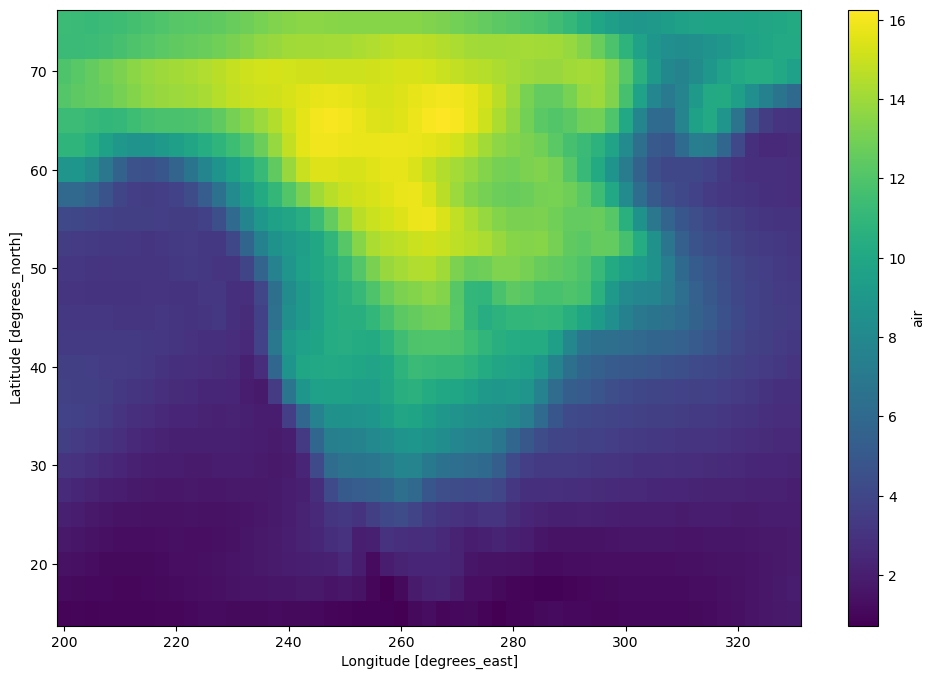

In [43]:
dair_resample.load().plot(figsize=(12, 8))

### 进一步学习

xarray 和 zarr 都有自己的教程，会讲得更深入：

* [Zarr 教程](https://zarr.readthedocs.io/en/stable/tutorial.html)
* [Xarray 教程](https://tutorial.xarray.dev/intro.html)


## 关闭集群

养成习惯：自己创建的 Dask 集群用完后都关掉。


In [44]:
client.shutdown()